### Импорты и настройка конфигурации

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

In [73]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 50)

### Выгразка данных

In [74]:
path_dir_data = r"./data/data"
path_dir_submissions = r"./data/submit"

In [75]:
authors = pd.read_csv(path_dir_data + "/authors.csv")
book_genres = pd.read_csv(path_dir_data + "/book_genres.csv")
editions = pd.read_csv(path_dir_data + "/editions.csv")
genres = pd.read_csv(path_dir_data + "/genres.csv")
interactions = pd.read_csv(path_dir_data + "/interactions.csv")
users = pd.read_csv(path_dir_data + "/users.csv")

candidates = pd.read_csv(path_dir_submissions + "/candidates.csv")
example_submission = pd.read_csv(path_dir_submissions + "/example_submission.csv")
targets = pd.read_csv(path_dir_submissions + "/targets.csv")

interactions["event_ts"] = pd.to_datetime(interactions["event_ts"])
# interactions = interactions[interactions["event_ts"] < pd.Timestamp("2025-01-14")]

### Первая проверка данных

#### Authors

In [76]:
authors.head()

,author_id,author_name
0,1,Грегори Бенфорд
1,6,Вячеслав Маркин
2,18,Эдвард де Боно
3,19,Василий Головачёв
4,21,Пауло Коэльо


#### Book_genres

In [77]:
book_genres.head()

,book_id,genre_id
0,20,433
1,20,1217
2,35,141
3,35,142
4,35,146


#### Genres

In [78]:
genres.head()

,genre_id,genre_name
0,1,Бизнес-книги
1,2,Банковское-дело
2,3,Бухучет-налогообложение-аудит
3,4,Государственное-и-муниципальное-управление
4,5,Делопроизводство


In [79]:
genres["genre_name"].value_counts().sort_values(ascending=False)

genre_name
Бизнес-книги                                  1
Банковское-дело                               1
Бухучет-налогообложение-аудит                 1
Государственное-и-муниципальное-управление    1
Делопроизводство                              1
                                             ..
Психологический-роман                         1
Славянское-фэнтези                            1
Ориентальное-фэнтези                          1
Вебтун                                        1
unknown                                       1
Name: count, Length: 586, dtype: int64

In [80]:
genres.info()

<class 'pandas.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   genre_id    586 non-null    int64
 1   genre_name  586 non-null    str  
dtypes: int64(1), str(1)
memory usage: 9.3 KB


In [81]:
for name in genres["genre_name"].tolist():
    mass = name.split(";")
    if len(mass) > 1:
        print(name)

#### Users

In [82]:
users.head()

,user_id,gender,age
0,560,2.0,9.0
1,3410,2.0,39.0
2,5620,1.0,42.0
3,5700,2.0,40.0
4,6120,2.0,32.0


In [83]:
users["gender"].value_counts()

gender
2.0    4311
1.0     585
Name: count, dtype: int64

In [84]:
users["age"].value_counts()

age
25.0    264
30.0    246
35.0    244
31.0    234
33.0    230
       ... 
77.0      1
99.0      1
72.0      1
87.0      1
6.0       1
Name: count, Length: 74, dtype: int64

Text(0.5, 1.0, 'Распределение по возрасту')

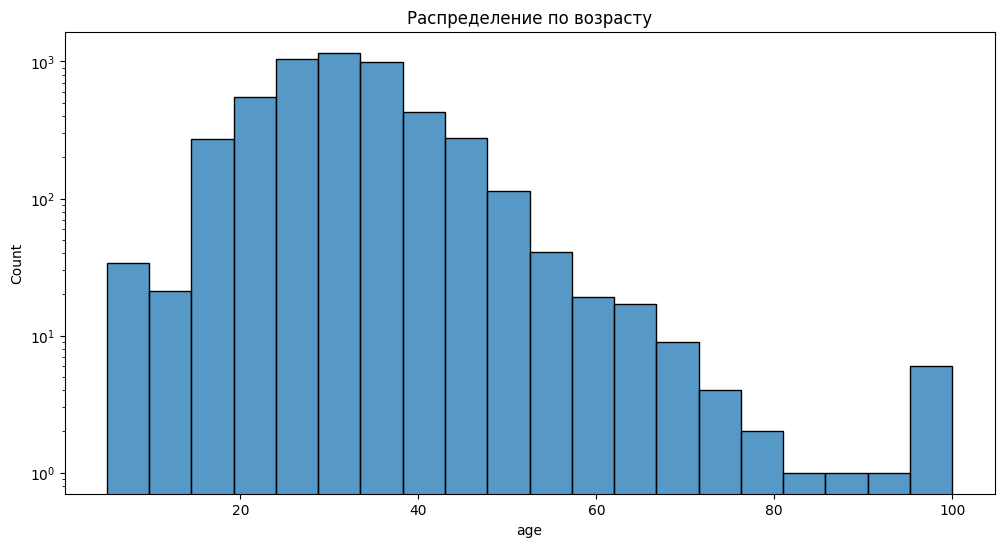

In [85]:
plt.figure(figsize=(12, 6))
sns.histplot(x="age", data=users, bins=20)
plt.yscale("log")
plt.title("Распределение по возрасту")

#### Editions

In [86]:
editions.head()

,edition_id,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description
0,1000000001,1093185,1.0,2000,18,119,9,Панорама времен,"Научный фантаст - тот, кто не стыдится первой ..."
1,1000000016,1548860,18.0,2005,16,119,1276,Развитие мышления: три пятидневных курса,"Талантливый ученый с мировым именем, изобретат..."
2,1000000020,20,21.0,2005,16,119,432,Вероника решает умереть,"Вторая изданная ""Софией"" книга Коэльо - совсем..."
3,1000000035,35,33.0,2002,18,119,122,Самое жуткое приключение,Когда Ларри Бойд и его друзья решили применить...
4,1000000070,891990,226891.0,2001,12,119,9,Танцы на снегу,«Звездные войны» от Сергея Лукьяненко? Да.\r\n...


In [87]:
editions.info()

<class 'pandas.DataFrame'>
RangeIndex: 134231 entries, 0 to 134230
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   edition_id        134231 non-null  int64  
 1   book_id           134231 non-null  int64  
 2   author_id         134231 non-null  float64
 3   publication_year  134231 non-null  int64  
 4   age_restriction   134231 non-null  int64  
 5   language_id       134231 non-null  int64  
 6   publisher_id      134231 non-null  int64  
 7   title             134231 non-null  str    
 8   description       126176 non-null  str    
dtypes: float64(1), int64(6), str(2)
memory usage: 9.2 MB


#### Interactions

In [88]:
interactions.head()

,user_id,edition_id,event_type,rating,event_ts
0,560,1012411658,2,6.0,2024-12-24 19:02:14
1,560,1008465904,2,6.0,2025-01-10 19:18:04
2,560,1001243738,2,10.0,2025-01-25 11:28:11
3,560,1009492501,2,8.0,2025-01-25 11:28:42
4,560,1000118974,2,8.0,2025-03-10 18:14:17


In [89]:
interactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 231210 entries, 0 to 231209
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     231210 non-null  int64         
 1   edition_id  231210 non-null  int64         
 2   event_type  231210 non-null  int64         
 3   rating      125369 non-null  float64       
 4   event_ts    231210 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 8.8 MB


In [90]:
interactions["user_id"].nunique()

5067

In [91]:
interactions["event_type"].value_counts()

event_type
2    146659
1     84551
Name: count, dtype: int64

In [92]:
interactions["user_id"].value_counts().sort_values(ascending=False)

user_id
1310260     290
4720390     288
5718550     288
1707730     287
11053490    287
           ... 
11802880      5
11811760      5
11867050      5
11903710      5
11940280      5
Name: count, Length: 5067, dtype: int64

In [93]:
interactions["event_ts"].min(), interactions["event_ts"].max()

(Timestamp('2024-10-14 18:48:56'), Timestamp('2025-04-12 12:44:23'))

#### Небольшая склейка, хочу проверить могут ли читать дети недостигшие возраста книги

In [94]:
interactions_editions = interactions.merge(editions, on="edition_id", how="left")
iter_users_editions = interactions_editions.merge(users, on="user_id", how="left")
iter_users_editions.head()

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age
0,560,1012411658,2,6.0,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2.0,9.0
1,560,1008465904,2,6.0,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2.0,9.0
2,560,1001243738,2,10.0,2025-01-25 11:28:11,1047228,11528.0,1984,16,119,1016,Evgenia Ivanovna,"Повесть Леонида Леонова, одного из крупнейших ...",2.0,9.0
3,560,1009492501,2,8.0,2025-01-25 11:28:42,6763729,2355.0,0,18,119,7,Transhumanism inc. + KGBT+,В комплект вошли два известных романа Виктора ...,2.0,9.0
4,560,1000118974,2,8.0,2025-03-10 18:14:17,127995,123194.0,2005,18,119,33,Тьма на ладони,"...Рекламный ролик, снятый 20 лет назад, в одн...",2.0,9.0


In [95]:
iter_users_editions[["age_restriction", "age"]].head()

,age_restriction,age
0,16,9.0
1,16,9.0
2,16,9.0
3,18,9.0
4,18,9.0


#### Вывод

Сразу видим, что возрастные ограничения не играют роли

Небольшой подитог: у нас есть множество таблиц, связанных через ключевые столбцы между собой. Датасеты небольшие, размером до 250000. Данные обширны, имеют много лишней информации. Всего примерно 5000 читателей найдено. Большая часть девушки. В основном читают люди 20-30 лет. После 45 происходит резкое снижение. Период сбора данных полгода. 

Вероятно стоит далее убрать лишние данные, сделать агрегации по пользователям, авторам, жанрам, полу, возрасту, книгам и возможно оценить тренды по сезонам.

### Общий датасет

In [96]:
genres_mas = (book_genres.groupby("book_id")["genre_id"].apply(list).reset_index())
genres_mas

,book_id,genre_id
0,20,"[433, 1217]"
1,35,"[141, 142, 146, 1223]"
2,54,"[125, 127, 433]"
3,69,"[127, 1280]"
4,72,"[128, 1311, 1312]"
...,...,...
105747,11339524,"[412, 441, 1223]"
105748,11340301,[433]
105749,11342272,[141]
105750,11342305,[1394]


In [97]:
train = interactions.merge(editions, on="edition_id", how="left")
train = train.merge(users, on="user_id", how="left")
train = train.merge(genres_mas, on="book_id", how="left")
train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age,genre_id
0,560,1012411658,2,6.0,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2.0,9.0,[433]
1,560,1008465904,2,6.0,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2.0,9.0,"[127, 128, 1276]"
2,560,1001243738,2,10.0,2025-01-25 11:28:11,1047228,11528.0,1984,16,119,1016,Evgenia Ivanovna,"Повесть Леонида Леонова, одного из крупнейших ...",2.0,9.0,[441]
3,560,1009492501,2,8.0,2025-01-25 11:28:42,6763729,2355.0,0,18,119,7,Transhumanism inc. + KGBT+,В комплект вошли два известных романа Виктора ...,2.0,9.0,[1394]
4,560,1000118974,2,8.0,2025-03-10 18:14:17,127995,123194.0,2005,18,119,33,Тьма на ладони,"...Рекламный ролик, снятый 20 лет назад, в одн...",2.0,9.0,"[127, 433]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231205,11951620,1010660789,2,10.0,2025-04-12 07:23:33,4043932,730235.0,2024,16,119,38337,Охота на Джека-потрошителя. Охота на князя Дра...,Англия. Конец XIX века. Семнадцатилетняя Одри ...,2.0,26.0,[433]
231206,11951620,1012417448,2,10.0,2025-04-12 07:24:00,8430743,624400.0,2024,18,119,69,Доля вероятности,Иззи не без мандража заходит в самолет — она б...,2.0,26.0,[433]
231207,11951620,1008619969,2,8.0,2025-04-12 07:24:42,6163753,513919.0,2023,18,119,53492,Виноват кофе,Илья ненавидит зеркала. Вид изуродованного шра...,2.0,26.0,[1222]
231208,11951620,1008619984,2,8.0,2025-04-12 07:25:03,6163756,2010817.0,2023,18,119,53492,Непара,Лиза Гаврилова и Алиса Нежнова – лучшие подруг...,2.0,26.0,[1222]


### Обработка NAN

In [98]:
train.isna().sum()

user_id                  0
edition_id               0
event_type               0
rating              105841
event_ts                 0
book_id                  0
author_id                0
publication_year         0
age_restriction          0
language_id              0
publisher_id             0
title                    0
description           4355
gender                6964
age                   3910
genre_id                 0
dtype: int64

In [99]:
train["rating"] = train["rating"].fillna(round(train["rating"].mean())).astype("int64")
train["description"] = train["description"].fillna("")
train["gender"] = train["gender"].fillna(train["gender"].mode()[0]).astype("int64")
train["age"] = train["age"].fillna(round(train["age"].mean())).astype("int64")

In [100]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 231210 entries, 0 to 231209
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           231210 non-null  int64         
 1   edition_id        231210 non-null  int64         
 2   event_type        231210 non-null  int64         
 3   rating            231210 non-null  int64         
 4   event_ts          231210 non-null  datetime64[us]
 5   book_id           231210 non-null  int64         
 6   author_id         231210 non-null  float64       
 7   publication_year  231210 non-null  int64         
 8   age_restriction   231210 non-null  int64         
 9   language_id       231210 non-null  int64         
 10  publisher_id      231210 non-null  int64         
 11  title             231210 non-null  str           
 12  description       231210 non-null  str           
 13  gender            231210 non-null  int64         
 14  age            

### Удаляем лишнее, дополнительный анализ (стадия 2)

In [101]:
train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age,genre_id
0,560,1012411658,2,6,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2,9,[433]
1,560,1008465904,2,6,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2,9,"[127, 128, 1276]"
2,560,1001243738,2,10,2025-01-25 11:28:11,1047228,11528.0,1984,16,119,1016,Evgenia Ivanovna,"Повесть Леонида Леонова, одного из крупнейших ...",2,9,[441]
3,560,1009492501,2,8,2025-01-25 11:28:42,6763729,2355.0,0,18,119,7,Transhumanism inc. + KGBT+,В комплект вошли два известных романа Виктора ...,2,9,[1394]
4,560,1000118974,2,8,2025-03-10 18:14:17,127995,123194.0,2005,18,119,33,Тьма на ладони,"...Рекламный ролик, снятый 20 лет назад, в одн...",2,9,"[127, 433]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231205,11951620,1010660789,2,10,2025-04-12 07:23:33,4043932,730235.0,2024,16,119,38337,Охота на Джека-потрошителя. Охота на князя Дра...,Англия. Конец XIX века. Семнадцатилетняя Одри ...,2,26,[433]
231206,11951620,1012417448,2,10,2025-04-12 07:24:00,8430743,624400.0,2024,18,119,69,Доля вероятности,Иззи не без мандража заходит в самолет — она б...,2,26,[433]
231207,11951620,1008619969,2,8,2025-04-12 07:24:42,6163753,513919.0,2023,18,119,53492,Виноват кофе,Илья ненавидит зеркала. Вид изуродованного шра...,2,26,[1222]
231208,11951620,1008619984,2,8,2025-04-12 07:25:03,6163756,2010817.0,2023,18,119,53492,Непара,Лиза Гаврилова и Алиса Нежнова – лучшие подруг...,2,26,[1222]


In [102]:
df_train = train.drop(columns=["description", "title", "age_restriction"])
df_train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,language_id,publisher_id,gender,age,genre_id
0,560,1012411658,2,6,2024-12-24 19:02:14,8387168,1085990.0,2024,119,123745,2,9,[433]
1,560,1008465904,2,6,2025-01-10 19:18:04,6064826,2338126.0,2023,119,1470,2,9,"[127, 128, 1276]"
2,560,1001243738,2,10,2025-01-25 11:28:11,1047228,11528.0,1984,119,1016,2,9,[441]
3,560,1009492501,2,8,2025-01-25 11:28:42,6763729,2355.0,0,119,7,2,9,[1394]
4,560,1000118974,2,8,2025-03-10 18:14:17,127995,123194.0,2005,119,33,2,9,"[127, 433]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
231205,11951620,1010660789,2,10,2025-04-12 07:23:33,4043932,730235.0,2024,119,38337,2,26,[433]
231206,11951620,1012417448,2,10,2025-04-12 07:24:00,8430743,624400.0,2024,119,69,2,26,[433]
231207,11951620,1008619969,2,8,2025-04-12 07:24:42,6163753,513919.0,2023,119,53492,2,26,[1222]
231208,11951620,1008619984,2,8,2025-04-12 07:25:03,6163756,2010817.0,2023,119,53492,2,26,[1222]


<Axes: xlabel='publication_year', ylabel='Count'>

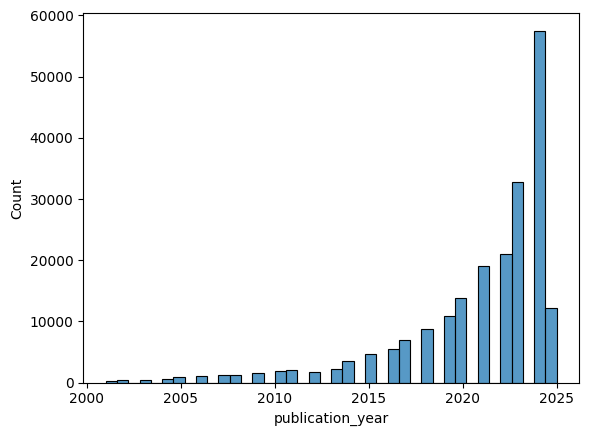

In [103]:
sns.histplot(x=df_train[df_train["publication_year"] > 2000]["publication_year"], bins=40)

### Агрегации

#### По годам публикации

In [104]:
read_in_publ = df_train.groupby("publication_year").size().reset_index(name="counts").sort_values(by="counts", ascending=False)
read_in_publ = read_in_publ.reset_index(drop=True)

rank_map = {}
for i, y in enumerate(read_in_publ["publication_year"]):
    if y == 2025 or y == 2026:
        rank_map[y] = 10
    else:
        rank_map[y] = max(1, 10 - i // 2)

df_train["year_rank"] = df_train["publication_year"].map(rank_map)


#### По количеству лет пользователей

In [105]:
age_rank_ = df_train.groupby("age").size().reset_index(name="counts").sort_values(by="counts", ascending=False).reset_index(drop=True)

age_rank_map = {}
for i, y in enumerate(age_rank_["age"]):
    age_rank_map[y] = max(1, 10 - i // 5)

df_train["age_rank"] = df_train["age"].map(age_rank_map)

#### По авторам

In [106]:
score_mass = []
score = 10
for i in range(3, 12):
    score_mass.append(score)
    score *= 2

number_month = len(df_train["event_ts"].dt.month.unique().tolist())
div = np.sqrt(6 / number_month)
score_mass = [score / div for score in score_mass]
print(div)
print(score_mass)

0.9258200997725514
[np.float64(10.801234497346433), np.float64(21.602468994692867), np.float64(43.20493798938573), np.float64(86.40987597877147), np.float64(172.81975195754293), np.float64(345.63950391508587), np.float64(691.2790078301717), np.float64(1382.5580156603435), np.float64(2765.116031320687)]


In [107]:
authors_rank_ = df_train.groupby("author_id").size().reset_index(name="counts").sort_values(by="counts", ascending=False).reset_index(drop=True)

authors_rank_map = {}
for i, y in enumerate(authors_rank_["author_id"]):
    for rank_inv, val in enumerate(score_mass):
        if i < val:
            authors_rank_map[y] = 10 - rank_inv
            break
    else:
        authors_rank_map[y] =  1

df_train["author_rank"] = df_train["author_id"].map(authors_rank_map)

#### По языку

In [108]:
df_train["language_flag"] = df_train["language_id"].apply(lambda x: 1 if x == 119 else 0)

In [109]:
user_multi_lang_flag = df_train.groupby("user_id")["language_id"].apply(set).apply(len).apply(lambda x: 1 if x > 1 else 0)
df_train["user_multi_lang_flag"] = df_train["user_id"].map(user_multi_lang_flag)

In [110]:
df_train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,language_id,publisher_id,gender,age,genre_id,year_rank,age_rank,author_rank,language_flag,user_multi_lang_flag
0,560,1012411658,2,6,2024-12-24 19:02:14,8387168,1085990.0,2024,119,123745,2,9,[433],10,1,1,1,1
1,560,1008465904,2,6,2025-01-10 19:18:04,6064826,2338126.0,2023,119,1470,2,9,"[127, 128, 1276]",10,1,1,1,1
2,560,1001243738,2,10,2025-01-25 11:28:11,1047228,11528.0,1984,119,1016,2,9,[441],1,1,1,1,1
3,560,1009492501,2,8,2025-01-25 11:28:42,6763729,2355.0,0,119,7,2,9,[1394],8,1,7,1,1
4,560,1000118974,2,8,2025-03-10 18:14:17,127995,123194.0,2005,119,33,2,9,"[127, 433]",1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231205,11951620,1010660789,2,10,2025-04-12 07:23:33,4043932,730235.0,2024,119,38337,2,26,[433],10,8,6,1,0
231206,11951620,1012417448,2,10,2025-04-12 07:24:00,8430743,624400.0,2024,119,69,2,26,[433],10,8,9,1,0
231207,11951620,1008619969,2,8,2025-04-12 07:24:42,6163753,513919.0,2023,119,53492,2,26,[1222],10,8,4,1,0
231208,11951620,1008619984,2,8,2025-04-12 07:25:03,6163756,2010817.0,2023,119,53492,2,26,[1222],10,8,6,1,0


#### По книгам

In [111]:
score_mass = []
score = 10
for i in range(3, 12):
    score_mass.append(score)
    score = round(score * 1.75)
print(score_mass)

[10, 18, 32, 56, 98, 172, 301, 527, 922]


In [112]:
book_rank_ = df_train.groupby("book_id").size().reset_index(name="counts").sort_values(by="counts", ascending=False).reset_index(drop=True)

book_rank_map = {}
for i, y in enumerate(book_rank_["book_id"]):
    for rank_inv, val in enumerate(score_mass):
        if i < val:
            book_rank_map[y] = 10 - rank_inv
            break
    else:
        book_rank_map[y] =  1

df_train["book_rank"] = df_train["book_id"].map(book_rank_map)

#### Жанры

In [113]:
df_train["n_genres"] = df_train["genre_id"].apply(len)

In [114]:
top_genres = df_train["genre_id"].explode().value_counts()

df_train["main_genre"] = df_train["genre_id"].apply(
    lambda xs: max(xs, key=lambda g: top_genres.get(g, 0))
)

In [115]:
df_train["genre_popularity_sum"] = df_train["genre_id"].apply(
    lambda xs: sum(top_genres.get(g, 0) for g in xs)
)

In [116]:
df_train["genre_popularity_mean"] = (
    df_train["genre_popularity_sum"] / df_train["n_genres"]
)

In [117]:
df_train["is_multigenre"] = (df_train["n_genres"] > 1).astype(int)

#### Пользователь\жанры (сколько книг с такими жанрами читал пользователь)

In [118]:
user_genre_cnt = df_train.explode("genre_id").groupby(["user_id", "genre_id"]).size()
df_train["user_genre_cnt"] = df_train.apply(lambda x: sum(user_genre_cnt.get((x.user_id, g) , 0 ) for g in x.genre_id), axis=1)

#### Пользователь\автор сколько взаимодействий

In [119]:
user_author_cnt = df_train.groupby(["user_id", "author_id"]).size()
df_train["user_author_hits"] = df_train.apply(
    lambda r: user_author_cnt.get((r.user_id, r.author_id), 0),
    axis=1
)

#### Логарифмирование некоторых признаков

In [120]:
df_train["genre_popularity_sum"] = np.log1p(df_train["genre_popularity_sum"])
df_train["genre_popularity_mean"] = np.log1p(df_train["genre_popularity_mean"])


#### Суммарный ранг

In [121]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 231210 entries, 0 to 231209
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                231210 non-null  int64         
 1   edition_id             231210 non-null  int64         
 2   event_type             231210 non-null  int64         
 3   rating                 231210 non-null  int64         
 4   event_ts               231210 non-null  datetime64[us]
 5   book_id                231210 non-null  int64         
 6   author_id              231210 non-null  float64       
 7   publication_year       231210 non-null  int64         
 8   language_id            231210 non-null  int64         
 9   publisher_id           231210 non-null  int64         
 10  gender                 231210 non-null  int64         
 11  age                    231210 non-null  int64         
 12  genre_id               231210 non-null  object        


In [122]:
df_train["total_rank"] = df_train[["author_rank", "rating", "book_rank", "year_rank"]].agg(sum, axis=1)

### Векторы пользователей и авторов

In [123]:
user_vec = df_train.groupby("user_id").agg(
    genre_pop_mean= ("genre_popularity_mean", "mean"),
    language_multi_flag= ("user_multi_lang_flag", "mean"),
    rating_mean= ("rating", "mean"),
    author_rank_mean= ("author_rank", "mean"),
    book_rank_mean= ("book_rank", "mean"),
    year_rank_mean= ("year_rank", "mean"),
    total_rank_mean= ("total_rank", "mean"),
    n_genres_mean=("n_genres", "mean")
)
user_ind = user_vec.index
user_vec = normalize(user_vec.values)

user_vec = pd.DataFrame(user_vec, index=user_ind)

In [124]:
author_vec = (
    df_train
    .groupby("author_id")
    .agg(
        genre_pop_mean=("genre_popularity_mean", "mean"),
        year_rank_mean=("year_rank", "mean"),
        book_rank_mean=("book_rank", "mean"),
        n_genres_mean=("n_genres", "mean"),
        rating_mean=("rating", "mean"),
    )
)
author_ind = author_vec.index
author_vec= normalize(author_vec.values)

author_vec = pd.DataFrame(author_vec, index=author_ind)

### Кластеры

In [125]:
user_clusters = KMeans(n_clusters=75, random_state=42).fit_predict(user_vec)
author_clusters = KMeans(n_clusters=45, random_state=42).fit_predict(author_vec)

In [126]:
user_vec["user_cluster"] = user_clusters
author_vec["author_cluster"] = author_clusters

In [127]:
df_train = df_train.merge(user_vec["user_cluster"], on="user_id", how="left")
df_train = df_train.merge(author_vec["author_cluster"], on="author_id", how="left")


In [128]:
COMMON_FEATS = list(
    set(user_vec.columns)
    & set(author_vec.columns)
)
COMMON_FEATS

[0, 1, 2, 3, 4]

In [129]:
u = user_vec.reset_index()[["user_id", *COMMON_FEATS]].rename(
    columns={c: f"{c}_u" for c in COMMON_FEATS}
)
a = author_vec.reset_index()[["author_id", *COMMON_FEATS]].rename(
    columns={c: f"{c}_a" for c in COMMON_FEATS}
)

df = df_train.merge(u, on="user_id", how="left")
df = df.merge(a, on="author_id", how="left")

u_mat = df[[f"{c}_u" for c in COMMON_FEATS]].to_numpy()
a_mat = df[[f"{c}_a" for c in COMMON_FEATS]].to_numpy()

num = (u_mat * a_mat).sum(axis=1)
den = (np.linalg.norm(u_mat, axis=1) * np.linalg.norm(a_mat, axis=1))
df_train["user_author_sim"] = num / den

### Последнее удаление, лишних фич

In [130]:
df_train.drop(columns=["publisher_id", "author_id", "book_id"], inplace=True)

### Итоговый датасет данных

In [131]:
df_train["event_ts"] = pd.to_datetime(df_train["event_ts"])
df_train

,user_id,edition_id,event_type,rating,event_ts,publication_year,language_id,gender,age,genre_id,year_rank,age_rank,author_rank,language_flag,user_multi_lang_flag,book_rank,n_genres,main_genre,genre_popularity_sum,genre_popularity_mean,is_multigenre,user_genre_cnt,user_author_hits,total_rank,user_cluster,author_cluster,user_author_sim
0,560,1012411658,2,6,2024-12-24 19:02:14,2024,119,2,9,[433],10,1,1,1,1,1,1,433,10.550931,10.550931,0,10,1,18,37,14,0.626447
1,560,1008465904,2,6,2025-01-10 19:18:04,2023,119,2,9,"[127, 128, 1276]",10,1,1,1,1,1,3,127,9.765145,8.666647,1,8,1,18,37,14,0.614979
2,560,1001243738,2,10,2025-01-25 11:28:11,1984,119,2,9,[441],1,1,1,1,1,1,1,441,9.677214,9.677214,0,1,1,13,37,30,0.681120
3,560,1009492501,2,8,2025-01-25 11:28:42,0,119,2,9,[1394],8,1,7,1,1,1,1,1394,9.586514,9.586514,0,2,1,24,37,16,0.645756
4,560,1000118974,2,8,2025-03-10 18:14:17,2005,119,2,9,"[127, 433]",1,1,1,1,1,1,2,433,10.914834,10.221705,1,16,1,11,37,44,0.736057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231205,11951620,1010660789,2,10,2025-04-12 07:23:33,2024,119,2,26,[433],10,8,6,1,0,1,1,433,10.550931,10.550931,0,2,1,27,40,16,0.631148
231206,11951620,1012417448,2,10,2025-04-12 07:24:00,2024,119,2,26,[433],10,8,9,1,0,7,1,433,10.550931,10.550931,0,2,1,36,40,22,0.751406
231207,11951620,1008619969,2,8,2025-04-12 07:24:42,2023,119,2,26,[1222],10,8,4,1,0,1,1,1222,9.427868,9.427868,0,2,1,23,40,40,0.548833
231208,11951620,1008619984,2,8,2025-04-12 07:25:03,2023,119,2,26,[1222],10,8,6,1,0,3,1,1222,9.427868,9.427868,0,2,1,27,40,43,0.583657


### Check

In [132]:
candidates

,user_id,edition_id
0,1310260,1002730309
1,1310260,1008890482
2,1310260,1009588990
3,1310260,1002062846
4,1310260,1009877656
...,...,...
1013395,11940280,1000564110
1013396,11940280,1010095864
1013397,11940280,1007526964
1013398,11940280,1008760405


In [133]:
ed_cnt = df_train.groupby(["user_id", "edition_id"]).size().reset_index(name="cnt")
ed_cnt[ed_cnt["cnt"] > 1].shape

(163, 3)

In [134]:
candidates = pd.read_csv(path_dir_submissions + "/candidates.csv")
example_submission = pd.read_csv(path_dir_submissions + "/example_submission.csv")
targets = pd.read_csv(path_dir_submissions + "/targets.csv")

In [135]:
candidates.head()

,user_id,edition_id
0,1310260,1002730309
1,1310260,1008890482
2,1310260,1009588990
3,1310260,1002062846
4,1310260,1009877656


In [136]:
example_submission.head()

,user_id,edition_id,rank
0,560,1008849829,1
1,560,1008326395,2
2,560,1002924304,3
3,560,1008885244,4
4,560,1012428389,5


In [137]:
targets.head()

,user_id
0,1310260
1,4720390
2,5718550
3,1707730
4,11053490


In [138]:
candidates["user_id"].sort_values().unique().tolist() == targets["user_id"].sort_values().tolist()

True

In [139]:
interactions["event_ts"] = pd.to_datetime(interactions["event_ts"])
interactions["event_ts"].dt.month.unique().tolist()

[12, 1, 3, 11, 2, 4, 10]

<Axes: xlabel='user_author_sim', ylabel='Count'>

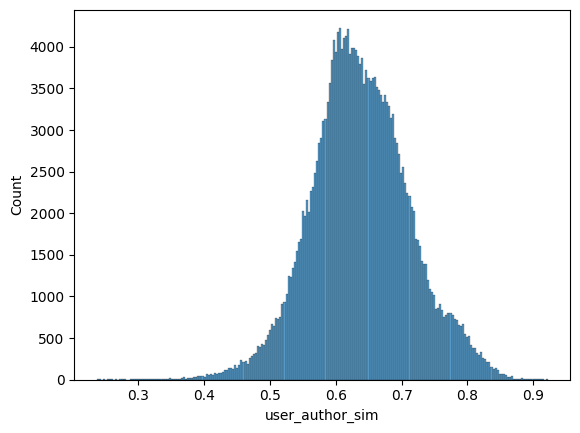

In [140]:
sns.histplot(df_train["user_author_sim"])

In [141]:
# authors = pd.read_csv(path_dir_data + "/authors.csv")
# book_genres = pd.read_csv(path_dir_data + "/book_genres.csv")
# editions = pd.read_csv(path_dir_data + "/editions.csv")
# genres = pd.read_csv(path_dir_data + "/genres.csv")
# interactions = pd.read_csv(path_dir_data + "/interactions.csv")
# users = pd.read_csv(path_dir_data + "/users.csv")

# candidates = pd.read_csv(path_dir_submissions + "/candidates.csv")
# example_submission = pd.read_csv(path_dir_submissions + "/example_submission.csv")
# targets = pd.read_csv(path_dir_submissions + "/targets.csv")

In [147]:
inter_unique = np.sort(interactions["edition_id"].unique())
can_unique = np.sort(candidates["edition_id"].unique())

inter_set = set(inter_unique)
can_set = set(can_unique)

In [148]:
only_inter = len(inter_set - can_set)
only_can = len(can_set - inter_set)
both = len(inter_set & can_set)

In [149]:
print(only_inter, only_can, both)

27844 36277 46684


In [158]:
editions.head(1)

,edition_id,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description
0,1000000001,1093185,1.0,2000,18,119,9,Панорама времен,"Научный фантаст - тот, кто не стыдится первой ..."


In [159]:
book_genres.head(1)

,book_id,genre_id
0,20,433


In [164]:
len(set(candidates["user_id"]) - set(interactions["user_id"]))

0

In [170]:
date_split = [pd.Timestamp("2024-11-14"), pd.Timestamp("2024-12-14"), pd.Timestamp("2025-01-14"),\
              pd.Timestamp("2025-02-14"), pd.Timestamp("2025-03-14"), None]


In [187]:
for i in range(len(date_split)):
    if i == 0:
        df_train_ = df_train[df_train["event_ts"] < date_split[i]]
    elif i == 5:
        df_train_ = df_train[df_train["event_ts"] > date_split[i - 1]]
    else:
        df_train_ = df_train[date_split[i - 1] < df_train["event_ts"]]
        df_train_ = df_train_[df_train_["event_ts"] < date_split[i]]

    df_train_ = df_train_.groupby("user_id")["edition_id"].size().reset_index(name="cnt").sort_values("cnt", ascending=False)
    print(df_train_.head(1))

     user_id  cnt
991  1313590  190
       user_id  cnt
3793  11349200  205
       user_id  cnt
4076  11468150  194
      user_id  cnt
1065  1297830  265
       user_id  cnt
4308  11845600  181
      user_id  cnt
1607  2893000  208


In [190]:
editions["publication_year"]

0         2000
1         2005
2         2005
3         2002
4         2001
          ... 
134226       0
134227    2025
134228       0
134229       0
134230       0
Name: publication_year, Length: 134231, dtype: int64

In [192]:
users.head(30)

,user_id,gender,age
0,560,2.0,9.0
1,3410,2.0,39.0
2,5620,1.0,42.0
3,5700,2.0,40.0
4,6120,2.0,32.0
5,7850,2.0,37.0
6,13450,1.0,NaN
7,13620,2.0,35.0
8,15470,2.0,36.0
9,15910,2.0,44.0
